In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional - for connecting to MySQL later
# from sqlalchemy import create_engine

sns.set_style("whitegrid")
plt.rcParams['figure.figsize']=(10,6)
print("Libraries loaded successfully")

Libraries loaded successfully


In [7]:
#load the dataset
df=pd.read_csv(r"C:\Users\singh\OneDrive\Desktop\Dashboards\upi3_fraud_dataset.csv")

#show basic info
print("Shape of data:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape of data: (100000, 14)

Column names:
['amount', 'avg_amount_30d', 'hour', 'device_change', 'txn_frequency', 'failed_attempts', 'location_change', 'account_age_days', 'ip_risk_score', 'vpa_new_handle', 'velocity_10min', 'remote_access_flag', 'mule_account_link', 'fraud']

First 5 rows:


,amount,avg_amount_30d,hour,device_change,txn_frequency,failed_attempts,location_change,account_age_days,ip_risk_score,vpa_new_handle,velocity_10min,remote_access_flag,mule_account_link,fraud
0,70699,10353,6,0,13,2,0,1040,88,0,8,0,0,0
1,29362,8086,0,0,15,3,0,569,66,0,3,0,0,0
2,70516,16189,11,0,5,0,0,43,66,0,3,0,0,0
3,77737,12626,16,0,17,2,0,710,27,0,4,0,0,0
4,41849,16602,17,0,3,4,0,703,83,0,8,0,0,0


In [8]:
#Check the datatype
print("Data Types:")
print(df.dtypes)

Data Types:
amount                int64
avg_amount_30d        int64
hour                  int64
device_change         int64
txn_frequency         int64
failed_attempts       int64
location_change       int64
account_age_days      int64
ip_risk_score         int64
vpa_new_handle        int64
velocity_10min        int64
remote_access_flag    int64
mule_account_link     int64
fraud                 int64
dtype: object


In [9]:
#Check the missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
amount                0
avg_amount_30d        0
hour                  0
device_change         0
txn_frequency         0
failed_attempts       0
location_change       0
account_age_days      0
ip_risk_score         0
vpa_new_handle        0
velocity_10min        0
remote_access_flag    0
mule_account_link     0
fraud                 0
dtype: int64


In [20]:
#checking the fraud distribution
print("Fraud distribution\n",df['fraud'].value_counts())

Fraud distribution
 fraud
0    99408
1      592
Name: count, dtype: int64


In [21]:
#checking fraud percentage
print("Fraud Percentage:")
print(df['fraud'].value_counts(normalize=True)*100)

Fraud Percentage:
fraud
0    99.408
1     0.592
Name: proportion, dtype: float64


In [22]:
df.describe()


,amount,avg_amount_30d,hour,device_change,txn_frequency,failed_attempts,location_change,account_age_days,ip_risk_score,vpa_new_handle,velocity_10min,remote_access_flag,mule_account_link,fraud
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50077.791810,10239.087000,11.495240,0.099080,10.016040,2.498070,0.080250,1000.576420,50.29079,0.049980,4.996570,0.031120,0.039480,0.005920
std,28887.047093,5631.121221,6.932258,0.298771,5.482523,1.708638,0.271681,577.969533,28.52075,0.217905,2.587231,0.173643,0.194735,0.076714
min,100.000000,500.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.00000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,24998.750000,5365.750000,5.000000,0.000000,5.000000,1.000000,0.000000,502.000000,26.00000,0.000000,3.000000,0.000000,0.000000,0.000000
50%,50119.000000,10231.500000,12.000000,0.000000,10.000000,3.000000,0.000000,999.000000,50.00000,0.000000,5.000000,0.000000,0.000000,0.000000
75%,75235.000000,15134.250000,18.000000,0.000000,15.000000,4.000000,0.000000,1503.000000,75.00000,0.000000,7.000000,0.000000,0.000000,0.000000
max,99999.000000,19999.000000,23.000000,1.000000,19.000000,5.000000,1.000000,1999.000000,99.00000,1.000000,9.000000,1.000000,1.000000,1.000000


In [23]:
#Checking the unique value in important column
print("Unique values in key columns:")
print("device_change:", df['device_change'].unique())
print("location_change:", df['location_change'].unique())
print("vpa_new_handle:", df['vpa_new_handle'].unique())
print("remote_access_flag:", df['remote_access_flag'].unique())
print("mule_account_link:", df['mule_account_link'].unique())
print("fraud:", df['fraud'].unique())


Unique values in key columns:
device_change: [0 1]
location_change: [0 1]
vpa_new_handle: [0 1]
remote_access_flag: [0 1]
mule_account_link: [0 1]
fraud: [0 1]


In [24]:
df.groupby('fraud')[['amount', 'avg_amount_30d', 'hour', 'velocity_10min', 
                     'ip_risk_score', 'account_age_days']].mean()

,amount,avg_amount_30d,hour,velocity_10min,ip_risk_score,account_age_days
fraud,,,,,,
0,50083.174905,10240.454833,11.493914,4.996509,50.287271,1000.754808
1,49173.868243,10009.402027,11.717905,5.006757,50.881757,970.621622


In [25]:
# Compare average values of Fraud vs Genuine transactions
comparison = df.groupby('fraud')[['amount', 'avg_amount_30d', 'hour', 'velocity_10min', 
                                   'ip_risk_score', 'account_age_days', 'txn_frequency',
                                   'failed_attempts']].mean()

print(comparison)

             amount  avg_amount_30d       hour  velocity_10min  ip_risk_score  \
fraud                                                                           
0      50083.174905    10240.454833  11.493914        4.996509      50.287271   
1      49173.868243    10009.402027  11.717905        5.006757      50.881757   

       account_age_days  txn_frequency  failed_attempts  
fraud                                                    
0           1000.754808      10.014033         2.497304  
1            970.621622      10.353041         2.626689  


In [26]:
# Check how often risk flags appear in Fraud vs Normal
risk_flags = ['device_change', 'location_change', 'vpa_new_handle', 
              'remote_access_flag', 'mule_account_link']

for col in risk_flags:
    print(f"\n===== {col} =====")
    print(pd.crosstab(df[col], df['fraud'], normalize='columns') * 100)


===== device_change =====
fraud                  0          1
device_change                      
0              90.083293  91.554054
1               9.916707   8.445946

===== location_change =====
fraud                    0          1
location_change                      
0                91.983543  90.540541
1                 8.016457   9.459459

===== vpa_new_handle =====
fraud                   0         1
vpa_new_handle                     
0               95.000402  95.27027
1                4.999598   4.72973

===== remote_access_flag =====
fraud                       0          1
remote_access_flag                      
0                   96.883551  97.635135
1                    3.116449   2.364865

===== mule_account_link =====
fraud                      0          1
mule_account_link                      
0                  96.048608  96.621622
1                   3.951392   3.378378


In [28]:
# 1. Fraud rate by Hour
hourly_fraud = df.groupby('hour')['fraud'].mean() * 100
print("Fraud % by Hour:")
print(hourly_fraud.sort_values(ascending=False).head(10))


Fraud % by Hour:
hour
23    0.796332
11    0.793848
5     0.738095
17    0.697038
14    0.664294
7     0.662565
16    0.662408
18    0.657586
10    0.629845
19    0.624700
Name: fraud, dtype: float64


In [29]:
# 2. Correlation of all columns with fraud
print("\nCorrelation with Fraud:")
print(df.corr()['fraud'].sort_values(ascending=False))


Correlation with Fraud:
fraud                 1.000000
failed_attempts       0.005809
txn_frequency         0.004744
location_change       0.004075
hour                  0.002479
ip_risk_score         0.001599
velocity_10min        0.000304
vpa_new_handle       -0.000950
mule_account_link    -0.002257
amount               -0.002415
avg_amount_30d       -0.003148
remote_access_flag   -0.003320
device_change        -0.003776
account_age_days     -0.004000
Name: fraud, dtype: float64


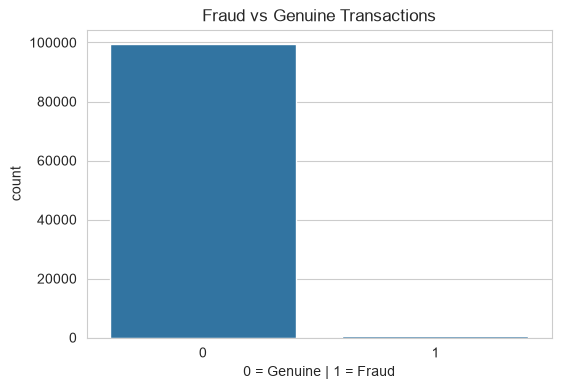

In [30]:
#Countplot Fraud vs Normal Count
plt.figure(figsize=(6,4))
sns.countplot(x='fraud', data=df)
plt.title('Fraud vs Genuine Transactions')
plt.xlabel('0 = Genuine | 1 = Fraud')
plt.show()

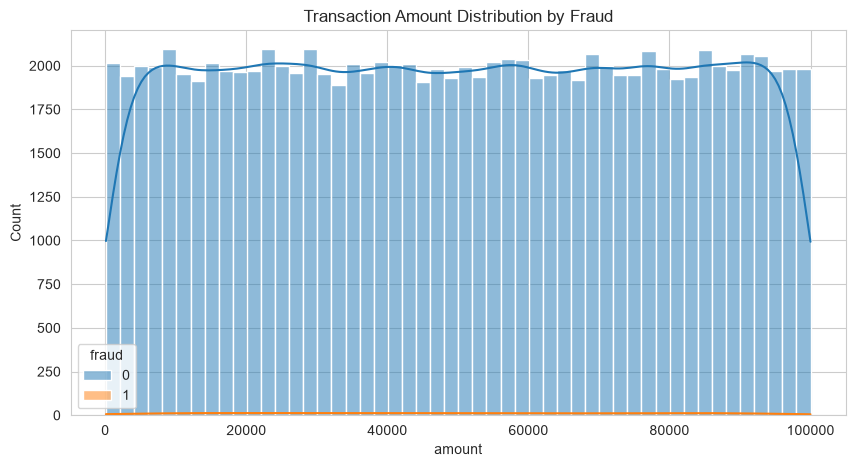

In [31]:
#histplot Distribution of Transactional amount
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='amount', hue='fraud', bins=50, kde=True)
plt.title('Transaction Amount Distribution by Fraud')
plt.show()

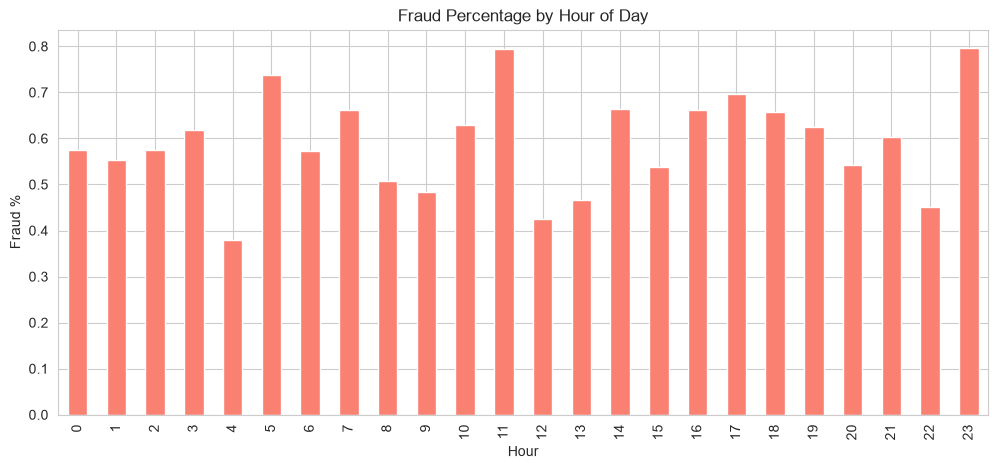

In [32]:
#barchart fraud by hour
plt.figure(figsize=(12,5))
hourly = df.groupby('hour')['fraud'].mean() * 100
hourly.plot(kind='bar', color='salmon')
plt.title('Fraud Percentage by Hour of Day')
plt.ylabel('Fraud %')
plt.xlabel('Hour')
plt.show()

In [33]:
#Simple Risk Score
# Create a simple Risk Score (0 to 5)
df['risk_score'] = 0

# Adding the points based on conditions
df.loc[df['ip_risk_score'] > 70, 'risk_score'] += 1
df.loc[df['velocity_10min'] >= 7, 'risk_score'] += 1
df.loc[df['failed_attempts'] >= 4, 'risk_score'] += 1
df.loc[df['account_age_days'] < 180, 'risk_score'] += 1
df.loc[df['amount'] > 70000, 'risk_score'] += 1

# Checking average risk score for Fraud vs Genuine
print(df.groupby('fraud')['risk_score'].mean())

# Seeing distribution of risk score
print("\nRisk Score Distribution:")
print(df['risk_score'].value_counts().sort_index())

fraud
0    1.353452
1    1.400338
Name: risk_score, dtype: float64

Risk Score Distribution:
risk_score
0    19982
1    38601
2    29297
3    10389
4     1644
5       87
Name: count, dtype: int64
